In [10]:
print('Kitui GIS Project started successfully')

Kitui GIS Project started successfully


In [11]:
import geopandas as gpd
import rasterio
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
print('GIS enviroment ready')

GIS enviroment ready


In [12]:
import geopandas as gpd
Kenya_counties = gpd.read_file('../data/raw/ken_admbnda_adm1_iebc_20191031.shp')
Kenya_counties.head()

,Shape_Leng,Shape_Area,ADM1_EN,ADM1_PCODE,ADM1_REF,ADM1ALT1EN,ADM1ALT2EN,ADM0_EN,ADM0_PCODE,date,validOn,validTo,geometry
0,5.932315,0.884732,Baringo,KE030,NaN,None,None,Kenya,KE,2017-11-03,2019-10-31,NaT,"POLYGON ((35.7839 1.65557, 35.78496 1.65554, 3..."
1,2.922220,0.198099,Bomet,KE036,NaN,None,None,Kenya,KE,2017-11-03,2019-10-31,NaT,"POLYGON ((35.4736 -0.3992, 35.47845 -0.40663, ..."
2,3.062486,0.245058,Bungoma,KE039,NaN,None,None,Kenya,KE,2017-11-03,2019-10-31,NaT,"POLYGON ((34.62017 1.10228, 34.62133 1.1016, 3..."
3,2.670396,0.147178,Busia,KE040,NaN,None,None,Kenya,KE,2017-11-03,2019-10-31,NaT,"POLYGON ((34.36097 0.7773, 34.36172 0.77696, 3..."
4,3.888933,0.244432,Elgeyo-Marakwet,KE028,NaN,None,None,Kenya,KE,2017-11-03,2019-10-31,NaT,"POLYGON ((35.69818 1.28225, 35.69788 1.27905, ..."


In [13]:
kitui = Kenya_counties[Kenya_counties['ADM1_EN'] == 'Kitui']
kitui

,Shape_Leng,Shape_Area,ADM1_EN,ADM1_PCODE,ADM1_REF,ADM1ALT1EN,ADM1ALT2EN,ADM0_EN,ADM0_PCODE,date,validOn,validTo,geometry
17,9.074169,2.475338,Kitui,KE015,NaN,None,None,Kenya,KE,2017-11-03,2019-10-31,NaT,"POLYGON ((38.32976 -0.06838, 38.331 -0.06838, ..."


<Axes: >

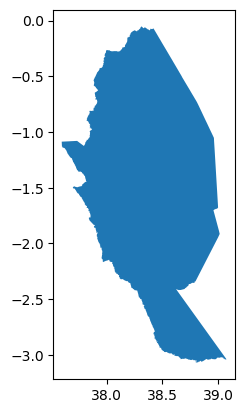

In [14]:
kitui.plot()

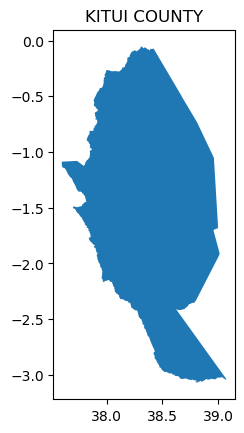

In [15]:
import matplotlib.pyplot as plt
kitui.plot()
plt.title('KITUI COUNTY')
plt.show()

In [16]:
kitui_proj = kitui.to_crs('EPSG:32737')
kitui_proj


,Shape_Leng,Shape_Area,ADM1_EN,ADM1_PCODE,ADM1_REF,ADM1ALT1EN,ADM1ALT2EN,ADM0_EN,ADM0_PCODE,date,validOn,validTo,geometry
17,9.074169,2.475338,Kitui,KE015,NaN,None,None,Kenya,KE,2017-11-03,2019-10-31,NaT,"POLYGON ((425417.577 9992441.312, 425555.542 9..."


In [17]:

kitui_proj.reset_index(drop=True)
kitui_proj.geom_type


17    Polygon
dtype: str

In [18]:
import os
processe_folder = '../data/processed'
if not os.path.exists(processe_folder):
    os.makedirs(processe_folder)

In [19]:
kitui_proj.to_file('../data/processed/kitui_boundary.shp')

c:\Users\user\miniconda3\envs\python_foundation\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Field date created as String field, though DateTime requested.
  ogr_write(
c:\Users\user\miniconda3\envs\python_foundation\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Field validOn created as String field, though DateTime requested.
  ogr_write(
c:\Users\user\miniconda3\envs\python_foundation\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Field validTo created as String field, though DateTime requested.
  ogr_write(


In [20]:
os.listdir('../data/processed')

['kitui_boundary.cpg',
 'kitui_boundary.dbf',
 'kitui_boundary.prj',
 'kitui_boundary.shp',
 'kitui_boundary.shx',
 'kitui_roads.cpg',
 'kitui_roads.dbf',
 'kitui_roads.prj',
 'kitui_roads.shp',
 'kitui_roads.shx',
 'kitui_soil.cpg',
 'kitui_soil.dbf',
 'kitui_soil.prj',
 'kitui_soil.shp',
 'kitui_soil.shx']

In [21]:
import geopandas as gpd
kitui_check = gpd.read_file('../data/processed/kitui_boundary.shp')
kitui_check.head()

,Shape_Leng,Shape_Area,ADM1_EN,ADM1_PCODE,ADM1_REF,ADM1ALT1EN,ADM1ALT2EN,ADM0_EN,ADM0_PCODE,date,validOn,validTo,geometry
0,9.074169,2.475338,Kitui,KE015,None,None,None,Kenya,KE,2017/11/03 00:00:00,2019/10/31 00:00:00,None,"POLYGON ((425417.577 9992441.312, 425555.542 9..."


In [22]:
kitui_check.crs

<Projected CRS: EPSG:32737>
Name: WGS 84 / UTM zone 37S
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 36°E and 42°E, southern hemisphere between 80°S and equator, onshore and offshore. Kenya. Mozambique. Tanzania.
- bounds: (36.0, -80.0, 42.0, 0.0)
Coordinate Operation:
- name: UTM zone 37S
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [23]:
roads = gpd.read_file('../data/raw/gis_osm_roads_free_1.shp')
roads.head(100)

,osm_id,code,fclass,name,ref,oneway,maxspeed,layer,bridge,tunnel,geometry
0,4685092,5114,secondary,Airport South Road,B10E,F,0,0,F,F,"LINESTRING (36.91442 -1.34465, 36.91427 -1.344..."
1,4716859,5115,tertiary,NaN,NaN,F,50,0,F,F,"LINESTRING (36.77939 -1.30009, 36.77943 -1.29994)"
2,4716860,5114,secondary,State House Avenue,D2001,B,0,0,F,F,"LINESTRING (36.80434 -1.28648, 36.80449 -1.286..."
3,4716861,5115,tertiary,Processional Way,NaN,B,0,0,F,F,"LINESTRING (36.81367 -1.28716, 36.81397 -1.287..."
4,4716862,5114,secondary,Kenyatta Avenue,UCB7-Nairobi,F,50,0,F,F,"LINESTRING (36.81026 -1.2895, 36.81034 -1.2894..."
...,...,...,...,...,...,...,...,...,...,...,...
95,4742005,5112,trunk,University Way,NaN,F,50,0,F,F,"LINESTRING (36.81514 -1.28159, 36.81531 -1.281..."
96,4742006,5112,trunk,University Way,NaN,F,50,0,F,F,"LINESTRING (36.8182 -1.28006, 36.81846 -1.2799..."
97,4742007,5141,service,Slip Road University Way,NaN,F,0,0,F,F,"LINESTRING (36.8144 -1.28001, 36.81443 -1.2800..."
98,4742013,5112,trunk,Uhuru Highway,A8,F,0,0,F,F,"LINESTRING (36.81313 -1.27572, 36.81316 -1.275..."


In [24]:
roads.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

<Axes: >

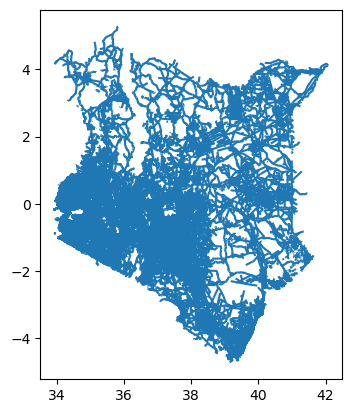

In [25]:
roads.plot()

In [26]:
roads_proj = roads.to_crs('EPSG:32737')
roads_proj.crs

<Projected CRS: EPSG:32737>
Name: WGS 84 / UTM zone 37S
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 36°E and 42°E, southern hemisphere between 80°S and equator, onshore and offshore. Kenya. Mozambique. Tanzania.
- bounds: (36.0, -80.0, 42.0, 0.0)
Coordinate Operation:
- name: UTM zone 37S
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [27]:
kitui_roads = gpd.clip(roads_proj,kitui_proj)

<Axes: >

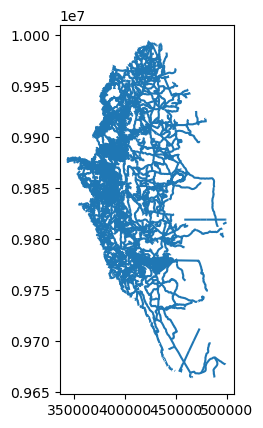

In [28]:
kitui_roads.plot()

In [29]:
kitui_roads.to_file('../data/processed/kitui_roads.shp')
os.listdir('../data/processed')

['kitui_boundary.cpg',
 'kitui_boundary.dbf',
 'kitui_boundary.prj',
 'kitui_boundary.shp',
 'kitui_boundary.shx',
 'kitui_roads.cpg',
 'kitui_roads.dbf',
 'kitui_roads.prj',
 'kitui_roads.shp',
 'kitui_roads.shx',
 'kitui_soil.cpg',
 'kitui_soil.dbf',
 'kitui_soil.prj',
 'kitui_soil.shp',
 'kitui_soil.shx']

Text(0.5, 1.0, 'Kitui county roads')

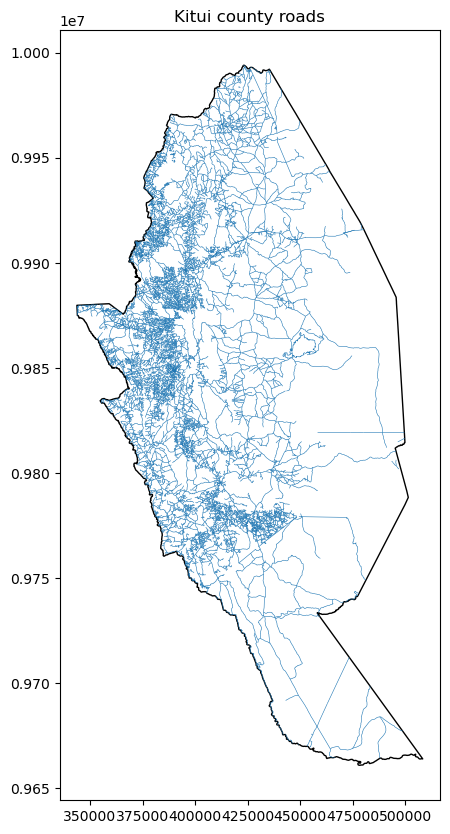

In [30]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10,10))
kitui_check.plot(ax=ax, color='none',edgecolor='black')
kitui_roads.plot(ax=ax,linewidth=0.4)
plt.title('Kitui county roads')


In [31]:
os.environ['SHAPE_RESTORE_SHX'] = 'YES'
kenya_soil = gpd.read_file('../data/raw/Proj_soil.shp')
kenya_soil

,AREA,PERIMETER,ILRIFNL_,SUID,BEDR,SDRA,SDRA_DESCR,PROP,PRID,PHAQ,...,SID,CLAY,CLAY_DESCR,TEXT,TEXT_DESCR,RSLO,RSLO_DESCR,LNDF,LNDF_DESCR,geometry
0,0.220,3.405,2,104,2.0,E,extremely slow,70,KE42/3,8.0,...,104,KA,kaolinitic,Y,very clayey,F,flat,LP,plain,"POLYGON ((34.84813 4.96832, 35.15091 5.22202, ..."
1,0.059,1.768,3,148,1.0,E,extremely slow,100,KE43-4,9.1,...,148,MO,montmorillonitic,C,clayey,F,flat,LP,plain,"POLYGON ((35.43548 5.0106, 35.43259 5.01293, 3..."
2,0.017,1.103,4,79,1.0,E,extremely slow,100,KE75/2-507,7.9,...,79,IN,interstratified,C,clayey,F,flat,LP,plain,"POLYGON ((35.84743 5.2999, 35.86553 5.27921, 3..."
3,0.004,0.419,5,151,1.0,W,well,50,KE1.25-180,0.0,...,151,NaN,NaN,C,clayey,DU,dune-shaped,SP,dissected plain,"POLYGON ((35.87146 5.1281, 35.86715 4.9315, 35..."
4,0.015,0.562,6,79,1.0,E,extremely slow,100,KE75/2-507,7.9,...,79,IN,interstratified,C,clayey,F,flat,LP,plain,"POLYGON ((34.91321 4.9672, 34.92296 4.97033, 3..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3254,0.000,0.122,3256,307,1.6,S,slow,50,KE202/1-277,5.8,...,307,IN,interstratified,C,clayey,F,flat,LP,plain,"POLYGON ((39.22947 -4.63247, 39.23794 -4.62288..."
3255,0.003,0.260,3257,308,1.6,W,well,70,NaN,0.0,...,308,MO,montmorillonitic,L,loamy,F,flat,LP,plain,"POLYGON ((39.32788 -4.61375, 39.33551 -4.61437..."
3256,0.001,0.131,3258,309,1.1,W,well,50,KE R3,6.3,...,309,KA,kaolinitic,L,loamy,F,flat,LP,plain,"POLYGON ((39.16591 -4.65724, 39.16766 -4.65462..."
3257,0.001,0.174,3259,307,1.6,S,slow,50,KE202/1-277,5.8,...,307,IN,interstratified,C,clayey,F,flat,LP,plain,"POLYGON ((39.20585 -4.64982, 39.22184 -4.64348..."


In [32]:
kenya_soil_proj = kenya_soil.to_crs('epsg:32737')

In [33]:
kitui_soil = gpd.clip(kenya_soil_proj,kitui_check)
kitui_soil

,AREA,PERIMETER,ILRIFNL_,SUID,BEDR,SDRA,SDRA_DESCR,PROP,PRID,PHAQ,...,SID,CLAY,CLAY_DESCR,TEXT,TEXT_DESCR,RSLO,RSLO_DESCR,LNDF,LNDF_DESCR,geometry
2785,0.153,4.611,2787,267,1.2,W,well,0,NaN,0.0,...,267,MO,montmorillonitic,C,clayey,NaN,NaN,LP,plain,"MULTIPOLYGON (((428682.168 9717709.981, 430471..."
2925,0.001,0.190,2927,246,1.0,W,well,60,KE149/2-3,5.8,...,246,KA,kaolinitic,L,loamy,F,flat,LP,plain,"POLYGON ((455223.606 9670044.6, 455960.687 967..."
2919,0.003,0.282,2921,251,1.6,E,extremely slow,100,KE190/3-4,5.7,...,251,KA,kaolinitic,C,clayey,F,flat,LP,plain,"POLYGON ((467738.072 9669746.572, 469317.95 96..."
2902,0.001,0.111,2904,244,1.0,S,slow,30,NaN,0.0,...,244,MO,montmorillonitic,C,clayey,F,flat,LP,plain,"POLYGON ((450987.275 9679651.482, 452851.336 9..."
2892,0.003,0.331,2894,251,1.6,E,extremely slow,100,KE190/3-4,5.7,...,251,KA,kaolinitic,C,clayey,F,flat,LP,plain,"POLYGON ((449158.807 9682593.753, 447851.611 9..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1826,0.001,0.159,1828,244,1.0,S,slow,30,NaN,0.0,...,244,MO,montmorillonitic,C,clayey,F,flat,LP,plain,"POLYGON ((415274.897 9913599.028, 415189.492 9..."
1788,0.002,0.281,1790,244,1.0,S,slow,30,NaN,0.0,...,244,MO,montmorillonitic,C,clayey,F,flat,LP,plain,"POLYGON ((423065.854 9924389.023, 423736.435 9..."
1789,0.001,0.104,1791,56,1.0,S,slow,100,NaN,0.0,...,56,MO,montmorillonitic,C,clayey,S,moderately steep,SM,medium-gradient mountain,"POLYGON ((420233.216 9920081.626, 420275.496 9..."
1576,0.114,2.255,1578,234,1.0,W,well,100,KE136/2-29,7.2,...,234,KA,kaolinitic,L,loamy,G,gently undulating,LP,plain,"POLYGON ((394489.45 9964104.688, 394301.765 99..."


In [34]:
kitui_soil.to_file('../data/processed/kitui_soil.shp')
os.listdir('../data/processed')

['kitui_boundary.cpg',
 'kitui_boundary.dbf',
 'kitui_boundary.prj',
 'kitui_boundary.shp',
 'kitui_boundary.shx',
 'kitui_roads.cpg',
 'kitui_roads.dbf',
 'kitui_roads.prj',
 'kitui_roads.shp',
 'kitui_roads.shx',
 'kitui_soil.cpg',
 'kitui_soil.dbf',
 'kitui_soil.prj',
 'kitui_soil.shp',
 'kitui_soil.shx']

In [35]:
kitui_soil.columns

Index(['AREA', 'PERIMETER', 'ILRIFNL_', 'SUID', 'BEDR', 'SDRA', 'SDRA_DESCR',
       'PROP', 'PRID', 'PHAQ', 'PHKC', 'EXNA', 'EXCK', 'CECS', 'DRAI',
       'DRAI_DESCR', 'RDEP', 'RDEP_DESCR', 'LITH', 'SLOP', 'RELI', 'SOIL',
       'SID', 'CLAY', 'CLAY_DESCR', 'TEXT', 'TEXT_DESCR', 'RSLO', 'RSLO_DESCR',
       'LNDF', 'LNDF_DESCR', 'geometry'],
      dtype='str')

In [36]:
kitui_soil['SOIL'].unique()

<StringArray>
[ 'UP9',   'L4',  'Pn8',  'F12',  'A10',  'F18',  'H13', 'Ul18',   'B9',
   'A5',  'Up4',  'Pd6',  'Ps3',  'Ps5',  'Ps6',  'Pf1',  'Pd4',  'Pt1',
  'A12', 'Ps15', 'Ps17', 'Ps20',   'B7', 'Pn12', 'Um19', 'UP10', 'Um27',
  'H15',  'H14',  'Pt2',  'F13',   'W1', 'Um21']
Length: 33, dtype: str

In [37]:
kitui_soil[['SOIL', 'TEXT','CLAY','DRAI']].head()

,SOIL,TEXT,CLAY,DRAI
2785,UP9,C,MO,NaN
2925,L4,L,KA,W
2919,Pn8,C,KA,W
2902,F12,C,MO,NaN
2892,Pn8,C,KA,W


Text(0.5, 1.0, 'Kitui soil texture)')

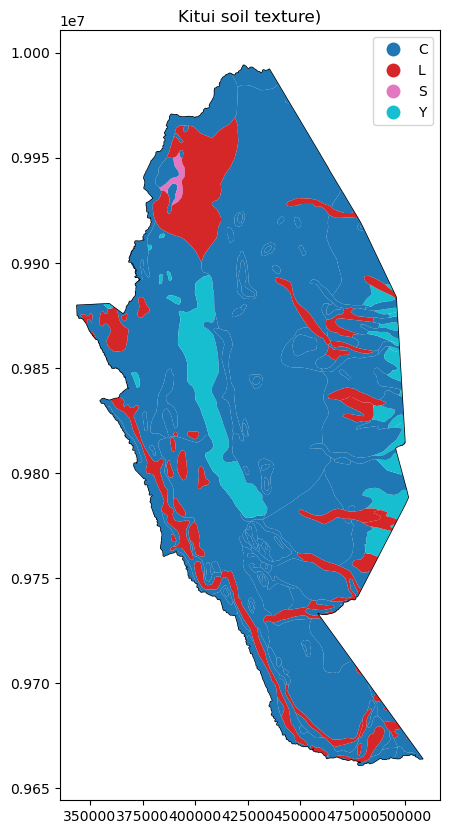

In [38]:
fig,ax = plt.subplots(figsize=(10,10))
kitui_check.plot(ax=ax,color='none',edgecolor='black')
kitui_soil.plot(ax=ax,column="TEXT",legend=True)
plt.title('Kitui soil texture)')

In [39]:
import geopandas as gpd
from pathlib import Path
processed = Path('../data/processed')
kituii = gpd.read_file(processed / 'kitui_boundary.shp')
road = gpd.read_file(processed / 'kitui_roads.shp')
soil = gpd.read_file(processed / 'kitui_soil.shp')

print('kitui crs',kituii.crs)
print('roads crs',road.crs)
print('soil crs',soil.crs)

print('kitui shape', kituii.shape)
print('kitui roads', road.shape)
print('kitui soil', soil.shape)

kitui crs EPSG:32737
roads crs EPSG:32737
soil crs EPSG:32737
kitui shape (1, 13)
kitui roads (13886, 11)
kitui soil (186, 32)


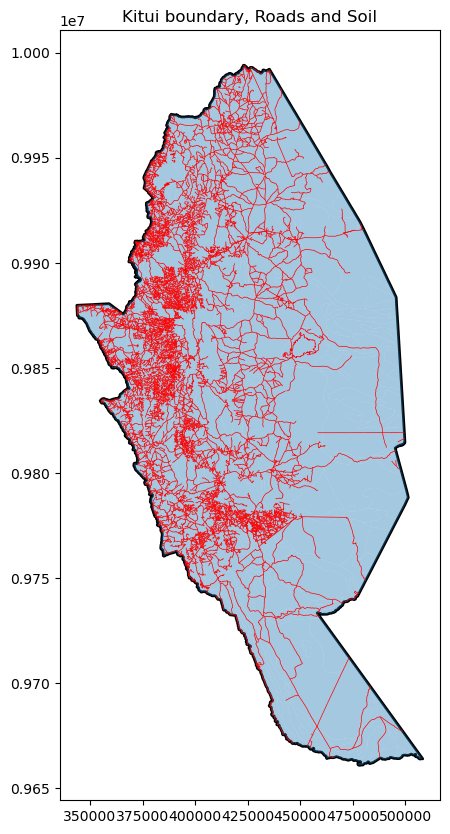

In [41]:
fig,ax = plt.subplots(figsize=(10,10))
kituii.plot(
    ax=ax,
    facecolor='None',
    edgecolor='black',
    linewidth=2
)

road.plot(
    ax=ax,
    color='red',
    linewidth=0.5

)

soil.plot(
    ax=ax,
    alpha=0.4

)

ax.set_title('Kitui boundary, Roads and Soil')
plt.show()